In [ ]:
%matplotlib inline

In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Conv2D, MaxPooling2D, Flatten
from keras import backend as K

In [ ]:
# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# input image dimensions
_, img_rows, img_cols = x_train.shape

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1) # Reshape (60000, 28, 28) -> (60000, 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)


# from uint8 (0-255) to float32 to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
n_classes = 10
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, n_classes)   # y_train = [array of numbers from 1 to 10]  ->   array of 10d vectors with 1 on the place of the digit, and 0 on the other ones
y_test = keras.utils.to_categorical(y_test, n_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
def shift_image(image, dx, dy):
    '''
    Сдвигает изображение на dx пикселей вправо и dy пикселей вниз.
    Пустые области заполняются нулями (черным).
    '''
    if len(image.shape) == 3:        # (28,28,1) -> (28,28)
        image = image.squeeze()

    h, w = image.shape
    shifted = np.zeros_like(image)

    # shifted image
    x_start = max(0, dx)
    x_end = min(w, w + dx)
    y_start = max(0, dy)
    y_end = min(h, h + dy)

    # original image
    or_x_start = max(0, -dx)
    or_x_end = min(w, w - dx)
    or_y_start = max(0, -dy)
    or_y_end = min(h, h - dy)


    shifted[y_start:y_end, x_start:x_end] = image[or_y_start:or_y_end, or_x_start:or_x_end]

    return shifted.reshape(28, 28, 1)

In [ ]:
def manual_augmentation(x_data, y_data, num_augmented, max_shift):


    # Списки для результатов
    x_augmented = []
    y_augmented = []

    # Добавляем оригиналы
    x_augmented.append(x_data)
    y_augmented.append(y_data)
    print("Изначально данных: ", len(x_data))

    # Создаем аугментированные копии
    for copy_num in range(1, num_augmented + 1):
        x_copy = np.zeros_like(x_data)

        for i in range(len(x_data)):
            # Случайный сдвиг для каждого изображения
            dx = np.random.randint(-max_shift, max_shift + 1)
            dy = np.random.randint(-max_shift, max_shift + 1)
            x_copy[i] = shift_image(x_data[i], dx, dy)

        x_augmented.append(x_copy)
        y_augmented.append(y_data)
        print(f"Копия {copy_num}: {len(x_data)} изображений со случайными сдвигами")

    # Объединяем все
    x_result = np.concatenate(x_augmented, axis=0)
    y_result = np.concatenate(y_augmented, axis=0)

    # Перемешиваем
    indices = np.random.permutation(len(x_result))
    x_result = x_result[indices]
    y_result = y_result[indices]

    print(f"Было: {len(x_data)} изображений")
    print(f"Стало: {len(x_result)} изображений (в {num_augmented + 1} раз больше)")
    print(f"Размер сдвигов: в переделах [-{max_shift}, {max_shift}] пикселей")

    return x_result, y_result

# Применяем к тренировочным данным

x_train_aug, y_train_aug = manual_augmentation(x_train, y_train, num_augmented=2, max_shift=6)

Изначально данных:  60000
Копия 1: 60000 изображений со случайными сдвигами
Копия 2: 60000 изображений со случайными сдвигами
Было: 60000 изображений
Стало: 180000 изображений (в 3 раз больше)
Размер сдвигов: в переделах [-6, 6] пикселей


In [ ]:
model_aug = Sequential()
model_aug.add(Conv2D(64, kernel_size=(3, 3),
                     activation='relu',
                     input_shape=input_shape, padding='same'))
model_aug.add(Dropout(0.2))
model_aug.add(MaxPooling2D(pool_size=(2, 2)))
model_aug.add(Conv2D(64, (3, 3), activation='relu'))
model_aug.add(Dropout(0.2))
model_aug.add(MaxPooling2D(pool_size=(2, 2)))
model_aug.add(Conv2D(64, (3, 3), activation='relu'))
model_aug.add(Dropout(0.2))
model_aug.add(Flatten())
model_aug.add(Dense(128, activation='relu'))
model_aug.add(Dropout(0.2))
model_aug.add(Dense(n_classes, activation='softmax'))


model_aug.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=keras.optimizers.Adadelta(learning_rate=1.0),
                  metrics=['accuracy'])

print(model_aug.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,986 (808.54 KB)

 Trainable params: 206,986 (808.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history_aug = model_aug.fit(x_train_aug, y_train_aug,
                            batch_size=128,
                            epochs=5,
                            verbose=1,
                            validation_data=(x_test, y_test))

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 416s 294ms/step - accuracy: 0.7585 - loss: 0.7179 - val_accuracy: 0.9867 - val_loss: 0.0418
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 427s 284ms/step - accuracy: 0.9707 - loss: 0.0986 - val_accuracy: 0.9907 - val_loss: 0.0322
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 442s 284ms/step - accuracy: 0.9811 - loss: 0.0618 - val_accuracy: 0.9939 - val_loss: 0.0212
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 394s 280ms/step - accuracy: 0.9844 - loss: 0.0508 - val_accuracy: 0.9934 - val_loss: 0.0214
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 398s 283ms/step - accuracy: 0.9872 - loss: 0.0417 - val_accuracy: 0.9949 - val_loss: 0.0183


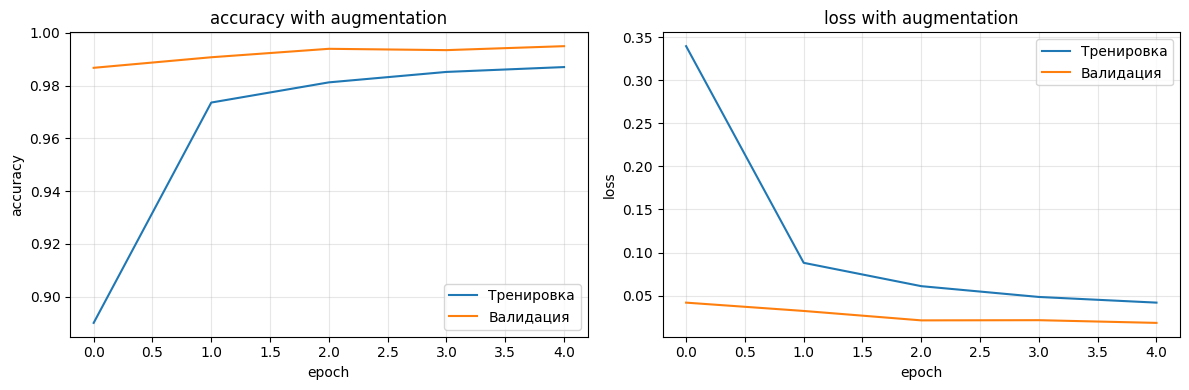

In [ ]:
# Графики обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_aug.history['accuracy'], label='Тренировка')
plt.plot(history_aug.history['val_accuracy'], label='Валидация')
plt.title('accuracy with augmentation')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_aug.history['loss'], label='Тренировка')
plt.plot(history_aug.history['val_loss'], label='Валидация')
plt.title('loss with augmentation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
right_shifts_acc = {}
print("\nCдвиги вправо:")
for dx in range(0, 15):
    x_test_shifted_right = np.zeros_like(x_test)
    for i in range(len(x_test)):
        x_test_shifted_right[i] = shift_image(x_test[i], dx, 0)

    score = model_aug.evaluate(x_test_shifted_right, y_test, verbose=0)
    right_shifts_acc[dx] = score[1]
    print(f'Сдвиг вправо на {dx} пикселей: accuracy = {score[1]:.4f}')


Cдвиги вправо:
Сдвиг вправо на 0 пикселей: accuracy = 0.9949
Сдвиг вправо на 1 пикселей: accuracy = 0.9943
Сдвиг вправо на 2 пикселей: accuracy = 0.9936
Сдвиг вправо на 3 пикселей: accuracy = 0.9935
Сдвиг вправо на 4 пикселей: accuracy = 0.9930
Сдвиг вправо на 5 пикселей: accuracy = 0.9912
Сдвиг вправо на 6 пикселей: accuracy = 0.9873
Сдвиг вправо на 7 пикселей: accuracy = 0.9778
Сдвиг вправо на 8 пикселей: accuracy = 0.9508
Сдвиг вправо на 9 пикселей: accuracy = 0.8713
Сдвиг вправо на 10 пикселей: accuracy = 0.7548
Сдвиг вправо на 11 пикселей: accuracy = 0.5861
Сдвиг вправо на 12 пикселей: accuracy = 0.4025
Сдвиг вправо на 13 пикселей: accuracy = 0.2802
Сдвиг вправо на 14 пикселей: accuracy = 0.2101


In [ ]:
test_accuracies = {}
max_shift = 10

for shift in range(0, max_shift + 1):
    x_test_shifted = np.zeros_like(x_test)  # empty, the same size as x_test

    for i in range(len(x_test)):
        dx = np.random.randint(-shift, shift + 1)  # random shift in [-shift, shift +1] 'cause  np.random.randint(a, b) gets a =< N < b
        dy = np.random.randint(-shift, shift + 1)
        x_test_shifted[i] = shift_image(x_test[i], dx, dy)

    score = model_aug.evaluate(x_test_shifted, y_test, verbose=0)
    test_accuracies[shift] = score[1]
    print(f'Случайный сдвиг до {shift} пикселей: accuracy = {score[1]:.4f}')

Случайный сдвиг до 0 пикселей: accuracy = 0.9949
Случайный сдвиг до 1 пикселей: accuracy = 0.9940
Случайный сдвиг до 2 пикселей: accuracy = 0.9945
Случайный сдвиг до 3 пикселей: accuracy = 0.9934
Случайный сдвиг до 4 пикселей: accuracy = 0.9935
Случайный сдвиг до 5 пикселей: accuracy = 0.9935
Случайный сдвиг до 6 пикселей: accuracy = 0.9899
Случайный сдвиг до 7 пикселей: accuracy = 0.9834
Случайный сдвиг до 8 пикселей: accuracy = 0.9654
Случайный сдвиг до 9 пикселей: accuracy = 0.9174
Случайный сдвиг до 10 пикселей: accuracy = 0.8431


**СРАВНЕНИЕ ДВУХ МОДЕЛЕЙ**

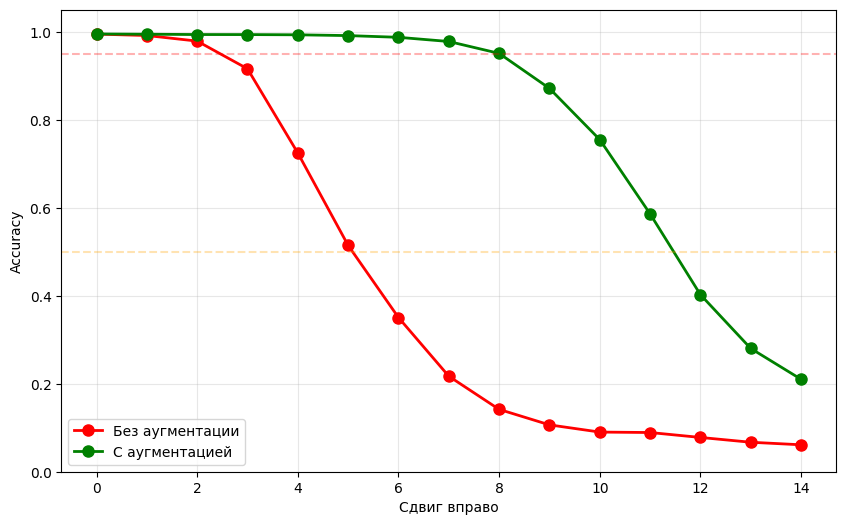

In [ ]:
original_acc = [0.9946, 0.9914, 0.9787, 0.9158, 0.7244, 0.5144, 0.3505, 0.2171, 0.1417, 0.1065, 0.0901, 0.0891, 0.0779, 0.0670, 0.0612]
augmented_acc = [0.9949, 0.9943, 0.9936, 0.9935, 0.9930, 0.9912, 0.9873, 0.9778, 0.9508, 0.8713, 0.7548, 0.5861, 0.4025, 0.2802, 0.2101]

plt.figure(figsize=(10, 6))
plt.plot(range(15), original_acc, 'ro-', linewidth=2, markersize=8, label='Без аугментации')
plt.plot(range(15), augmented_acc, 'go-', linewidth=2, markersize=8, label='С аугментацией')

plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.3)
plt.axhline(y=0.50, color='orange', linestyle='--', alpha=0.3)

plt.xlabel('Сдвиг вправо')
plt.ylabel('Accuracy')
plt.title('')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.show()